In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw

from scipy.stats import sem, t

from IPython.display import HTML

In [2]:
kiba_drugs = pd.read_csv('../data/kiba/drugs.csv')
kiba_proteins = pd.read_csv('../data/kiba/proteins.csv')
kiba = pd.read_csv('../data/kiba/affinities.csv')

kiba = kiba.merge(kiba_drugs, on='drug_id')
kiba = kiba.merge(kiba_proteins, on='protein_id')

kiba.head()

,drug_id,protein_id,affinity,smiles,target_sequence
0,0,0,12.599997,O=C(Nc1cc(C)cc(c1)C)Nc1ccc(cc1)c1c(C)sc2c1c(N)...,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...
1,1,1,11.500000,S=C1NC(=O)C(=C2C(=O)Nc3c2cc(Br)cc3)S1,MARTTSQLYDAVPIQSSVVLCSCPSPSMVRTQTESSTPPGIPGGSR...
2,2,2,11.200000,COC(=O)c1c(C)n2c(c1c1ccc(cc1)NC(=O)Nc1ccccc1)c...,MSDVAIVKEGWLHKRGEYIKTWRPRYFLLKNDGTFIGYKERPQDVD...
3,3,3,11.699999,ON=C1c2cc(ccc2-c2c1cccc2)NS(=O)(=O)c1cccc(c1)Br,MKSGSGGGSPTSLWGLLFLSAALSLWPTSGEICGPGIDIRNDYQQL...
4,4,4,11.200000,FC(c1cc(ccc1Cn1nnc(c1)c1ccc2c(c1)cn[nH]2)C(F)(...,MEAPLRPAADILRRNPQQDYELVQRVGSGTYGDVYKARNVHTGELA...


In [3]:
n_drugs = kiba['drug_id'].nunique()
n_proteins = kiba['protein_id'].nunique()
n_affs = len(kiba)

print(f"Number of drugs: {n_drugs}\nNumber of proteins: {n_proteins}\nMeasured affinities: {n_affs} / {n_drugs * n_proteins} = {100 * n_affs / (n_drugs * n_proteins):.2f}%")

Number of drugs: 2068
Number of proteins: 229
Measured affinities: 117657 / 473572 = 24.84%


In [4]:
kiba['Protein Length'] = kiba['target_sequence'].str.len()
kiba['SMILES Length'] = kiba['smiles'].str.len()

kiba.head()

,drug_id,protein_id,affinity,smiles,target_sequence,Protein Length,SMILES Length
0,0,0,12.599997,O=C(Nc1cc(C)cc(c1)C)Nc1ccc(cc1)c1c(C)sc2c1c(N)...,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,970,50
1,1,1,11.500000,S=C1NC(=O)C(=C2C(=O)Nc3c2cc(Br)cc3)S1,MARTTSQLYDAVPIQSSVVLCSCPSPSMVRTQTESSTPPGIPGGSR...,556,37
2,2,2,11.200000,COC(=O)c1c(C)n2c(c1c1ccc(cc1)NC(=O)Nc1ccccc1)c...,MSDVAIVKEGWLHKRGEYIKTWRPRYFLLKNDGTFIGYKERPQDVD...,480,53
3,3,3,11.699999,ON=C1c2cc(ccc2-c2c1cccc2)NS(=O)(=O)c1cccc(c1)Br,MKSGSGGGSPTSLWGLLFLSAALSLWPTSGEICGPGIDIRNDYQQL...,1367,47
4,4,4,11.200000,FC(c1cc(ccc1Cn1nnc(c1)c1ccc2c(c1)cn[nH]2)C(F)(...,MEAPLRPAADILRRNPQQDYELVQRVGSGTYGDVYKARNVHTGELA...,846,54


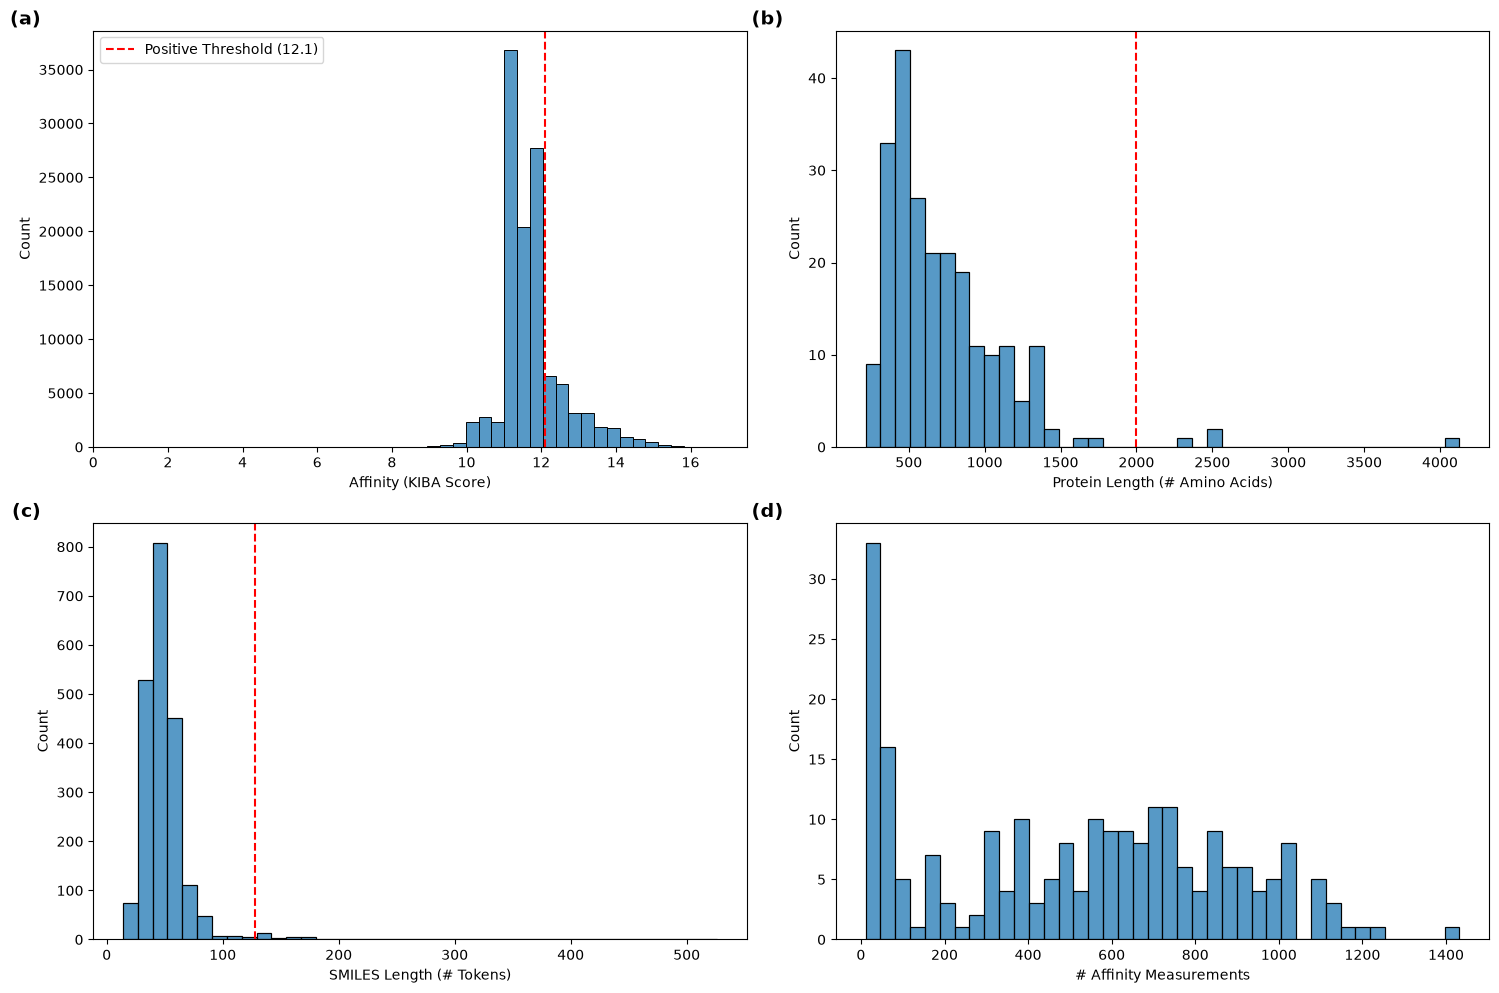

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Affinity
sns.histplot(kiba['affinity'], bins=50, ax=axes[0, 0])
axes[0, 0].axvline(
    12.1, color='red', linestyle='--',
    label='Positive Threshold (12.1)'
)
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 17.5)
axes[0, 0].set_xlabel('Affinity (KIBA Score)')

# Protein length
sns.histplot(
    kiba.drop_duplicates('protein_id')['Protein Length'],
    bins=40,
    ax=axes[0, 1]
)
axes[0, 1].axvline(2000, color='red', linestyle='--')
axes[0, 1].set_xlabel('Protein Length (# Amino Acids)')

# SMILES length
sns.histplot(
    kiba.drop_duplicates('drug_id')['SMILES Length'],
    bins=40,
    ax=axes[1, 0]
)
axes[1, 0].axvline(128, color='red', linestyle='--')
axes[1, 0].set_xlabel('SMILES Length (# Tokens)')

# Number of affinity measurements per protein
measurements_per_protein = kiba.groupby('protein_id').size()

sns.histplot(
    measurements_per_protein,
    bins=40,
    ax=axes[1, 1]
)
axes[1, 1].set_xlabel('# Affinity Measurements')

for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(
        -0.08, 1.05,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='right'
    )

plt.tight_layout()
plt.show()

In [6]:
print(kiba['affinity'].describe())

count    117657.000000
mean         11.721431
std           0.834363
min           0.000000
25%          11.200000
50%          11.527128
75%          11.923909
max          17.200179
Name: affinity, dtype: float64


In [7]:
print("Number of proteins with less than 50 amino acids:", (kiba.drop_duplicates('protein_id')['Protein Length'] < 50).sum())
print("Number of proteins with more than 2000 amino acids:", (kiba.drop_duplicates('protein_id')['Protein Length'] > 2000).sum())
print("Number of proteins with less than 5 affinity measurements:", (kiba.groupby('protein_id').size() < 5).sum())
print("UniProt search showed that they are PRKDC, mTOR, LRRK2 and ROS1")

Number of proteins with less than 50 amino acids: 0
Number of proteins with more than 2000 amino acids: 4
Number of proteins with less than 5 affinity measurements: 0
UniProt search showed that they are PRKDC, mTOR, LRRK2 and ROS1


In [8]:
print("Number of drugs with SMILES length greater than 128:", (kiba.drop_duplicates('drug_id')['SMILES Length'] > 128).sum())

Number of drugs with SMILES length greater than 128: 32


In [9]:
print("Before filters:")
print("Number of drugs:", kiba['drug_id'].nunique())
print("Number of proteins:", kiba['protein_id'].nunique())
print("Number of measured affinities:", len(kiba))
print("Density of measured affinities: {:.2f}%".format(100 * len(kiba) / (kiba['drug_id'].nunique() * kiba['protein_id'].nunique())))
print("After filters:")
kiba_filtered = kiba[(kiba['Protein Length'] >= 50) & (kiba['Protein Length'] <= 2000) & (kiba['SMILES Length'] <= 126) & ~kiba['smiles'].str.contains('.', regex=False)]
# only proteins with at least 5 affinity measurements
protein_counts = kiba_filtered['protein_id'].value_counts()
kiba_filtered = kiba_filtered[kiba_filtered['protein_id'].isin(protein_counts[protein_counts >= 5].index)]
print("Number of drugs after filters:", kiba_filtered['drug_id'].nunique())
print("Number of proteins after filters:", kiba_filtered['protein_id'].nunique())
print("Number of measured affinities after filters:", len(kiba_filtered))
print("Density of measured affinities after filters: {:.2f}%".format(100 * len(kiba_filtered) / (kiba_filtered['drug_id'].nunique() * kiba_filtered['protein_id'].nunique())))

Before filters:
Number of drugs: 2068
Number of proteins: 229
Number of measured affinities: 117657
Density of measured affinities: 24.84%
After filters:
Number of drugs after filters: 2015
Number of proteins after filters: 225
Number of measured affinities after filters: 115829
Density of measured affinities after filters: 25.55%


In [10]:
subset = kiba[kiba['SMILES Length'] > 128].drop_duplicates('drug_id')

mols = [m for m in subset['smiles'].apply(Chem.MolFromSmiles) if m is not None][:10]

opts = Draw.MolDrawOptions()
opts.padding = 0.0

svg = Draw._MolsToGridSVG(
    mols,
    molsPerRow=5,
    subImgSize=(400, 400),
    drawOptions=opts,
)
if isinstance(svg, bytes):
    svg = svg.decode("utf-8", errors="replace")
HTML(svg)

In [11]:
def ci95(x):
    if len(x) < 2:
        return (float("nan"), float("nan"))
    mean = x.mean()
    margin = t.ppf(0.975, len(x) - 1) * sem(x)
    return mean - margin, mean + margin
def ci80(x):
    if len(x) < 2:
        return (float("nan"), float("nan"))
    mean = x.mean()
    margin = t.ppf(0.9, len(x) - 1) * sem(x)
    return mean - margin, mean + margin
def ci90(x):
    if len(x) < 2:
        return (float("nan"), float("nan"))
    mean = x.mean()
    margin = t.ppf(0.95, len(x) - 1) * sem(x)
    return mean - margin, mean + margin

In [12]:
protein_stats = kiba_filtered.groupby("protein_id")["affinity"].agg(
    affinities=list,
    mean="mean",
    n="size",
    ci95=ci95
)

protein_stats[["ci_low", "ci_high"]] = pd.DataFrame(
    protein_stats["ci95"].tolist(),
    index=protein_stats.index,
    columns=["ci_low", "ci_high"],
)

protein_stats

,affinities,mean,n,ci95,ci_low,ci_high
protein_id,,,,,,
0,"[12.599996932, 11.500000186, 11.500000186, 13....",11.990701,701,"(11.926446152362331, 12.054955640967197)",11.926446,12.054956
1,"[11.500000186, 11.500000186, 13.399988938, 11....",11.678417,699,"(11.640021310115973, 11.716813132564997)",11.640021,11.716813
2,"[11.200000128, 11.200000128, 11.999998417, 10....",11.328055,896,"(11.28258231751322, 11.373526886573831)",11.282582,11.373527
3,"[11.699999383, 11.699999383, 11.699999383, 11....",11.864981,899,"(11.821687792792709, 11.908274637448667)",11.821688,11.908275
4,"[11.200000128, 11.200000128, 11.200000128, 11....",11.960025,649,"(11.887488656676721, 12.032561096525127)",11.887489,12.032561
...,...,...,...,...,...,...
224,"[11.673488739, 13.668636236, 12.300659451, 12....",12.228583,15,"(11.693726023990246, 12.763440024809752)",11.693726,12.763440
225,"[11.1, 12.08940535, 11.344887734, 11.1, 11.1, ...",11.126431,12,"(10.895609945168449, 11.35725278066488)",10.895610,11.357253
226,"[10.702059991, 10.702059991, 11.1, 10.70205999...",10.982346,11,"(10.697365757203313, 11.267326865887595)",10.697366,11.267327


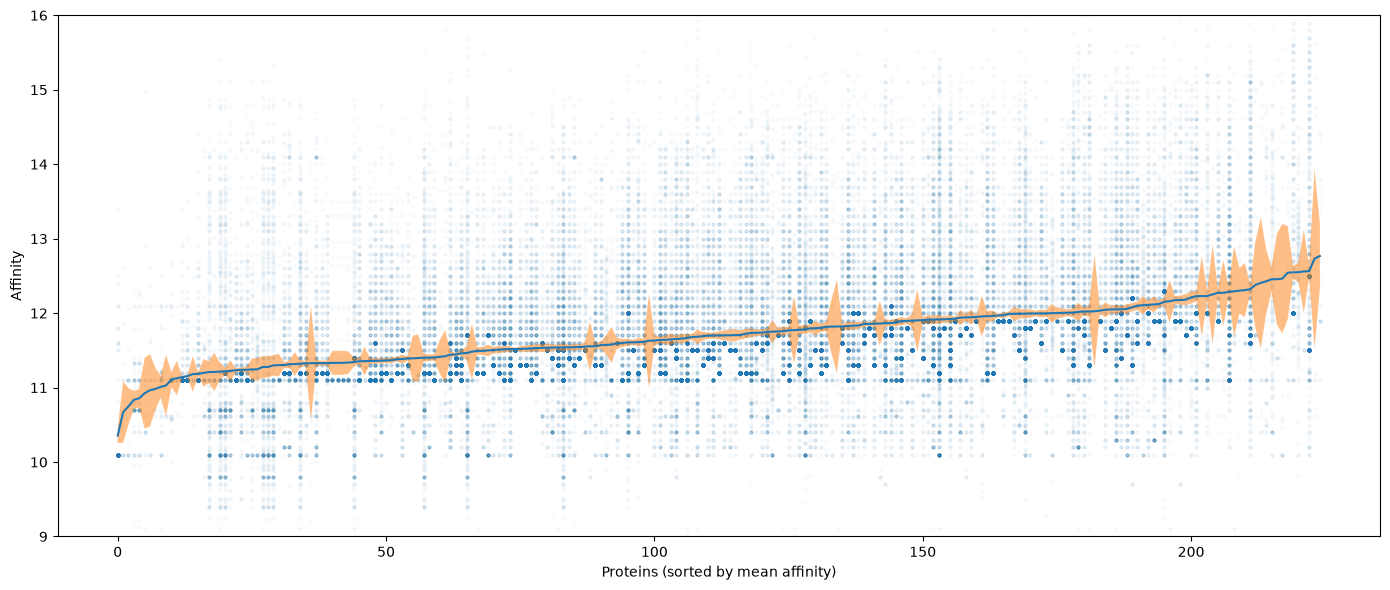

In [13]:
protein_stats = protein_stats.sort_values("mean").reset_index(drop=True)
dots = protein_stats["affinities"].explode()

plt.figure(figsize=(14, 6))
plt.scatter(dots.index, dots.values, s=5, alpha=0.02)
plt.plot(protein_stats.index, protein_stats["mean"])
plt.fill_between(protein_stats.index, protein_stats["ci_low"], protein_stats["ci_high"], alpha=0.5)

plt.xlabel("Proteins (sorted by mean affinity)")
plt.ylabel("Affinity")
plt.ylim(9, 16)
plt.tight_layout()
plt.show()

In [14]:
drug_stats = kiba_filtered.groupby("drug_id")["affinity"].agg(
    affinities=list,
    mean="mean",
    n="size",
    ci95=ci95
)

drug_stats[["ci_low", "ci_high"]] = pd.DataFrame(
    drug_stats["ci95"].tolist(),
    index=drug_stats.index,
    columns=["ci_low", "ci_high"],
)

drug_stats

,affinities,mean,n,ci95,ci_low,ci_high
drug_id,,,,,,
0,"[12.599996932, 12.399997603, 12.1, 13.39998893...",12.066560,135,"(11.912708986000405, 12.22041081765885)",11.912709,12.220411
1,"[11.500000186, 11.900000875, 11.800000504, 11....",11.712592,135,"(11.632171823786098, 11.79301223184353)",11.632172,11.793012
2,"[11.200000128, 11.500000186, 11.200000128, 11....",12.154551,77,"(11.954988086413268, 12.354114583326991)",11.954988,12.354115
3,"[11.699999383, 11.699999383, 11.699999383, 11....",11.618461,65,"(11.552191191168394, 11.684730851200836)",11.552191,11.684731
4,"[11.200000128, 11.200000128, 11.300000237, 11....",11.539497,119,"(11.453105543290015, 11.625887904878045)",11.453106,11.625888
...,...,...,...,...,...,...
2062,"[10.895880017, 10.844727495, 11.520216403, 12....",11.763384,10,"(11.082737882478146, 12.444030206321852)",11.082738,12.444030
2064,"[9.798970004, 9.798970004, 9.798970004, 9.7989...",9.798970,11,"(9.798970004, 9.798970004)",9.798970,9.798970
2065,"[13.383996656, 14.058607315, 14.1, 13.60863830...",13.226230,11,"(12.638806382344969, 13.813653855109576)",12.638806,13.813654


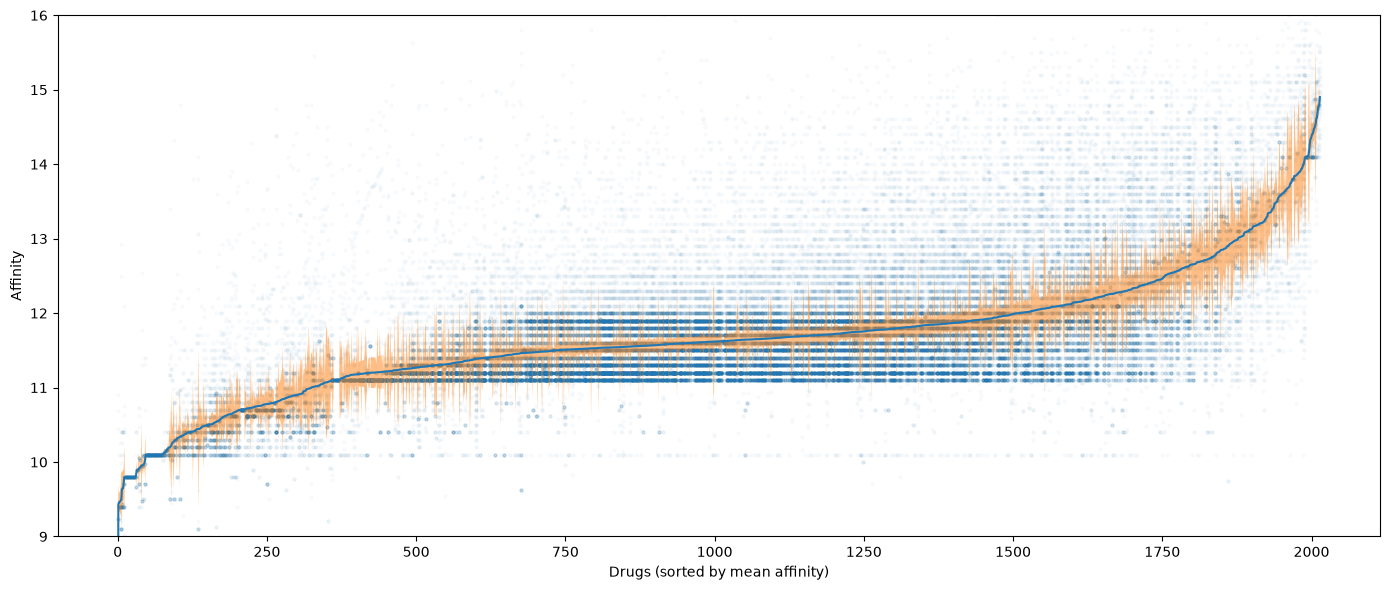

In [15]:
drug_stats = drug_stats.sort_values("mean").reset_index(drop=True)
dots = drug_stats["affinities"].explode()

plt.figure(figsize=(14, 6))
plt.scatter(dots.index, dots.values, s=5, alpha=0.02)
plt.plot(drug_stats.index, drug_stats["mean"])
plt.fill_between(drug_stats.index, drug_stats["ci_low"], drug_stats["ci_high"], alpha=0.5)

plt.xlabel("Drugs (sorted by mean affinity)")
plt.ylabel("Affinity")
plt.ylim(9, 16)
plt.tight_layout()
plt.show()

In [16]:
measurements_per_drug = kiba.groupby('drug_id').size()

print(f'Percentage of drugs measured against at least 2 proteins {(measurements_per_drug >= 2).mean() * 100}%')
print(f'Percentage of drugs measured against at least 3 proteins {(measurements_per_drug >= 3).mean() * 100}%')
print(f'Percentage of drugs measured against at least 4 proteins {(measurements_per_drug >= 4).mean() * 100}%')
print(f'Percentage of drugs measured against at least 5 proteins {(measurements_per_drug >= 5).mean() * 100}%')

Percentage of drugs measured against at least 2 proteins 100.0%
Percentage of drugs measured against at least 3 proteins 100.0%
Percentage of drugs measured against at least 4 proteins 100.0%
Percentage of drugs measured against at least 5 proteins 100.0%


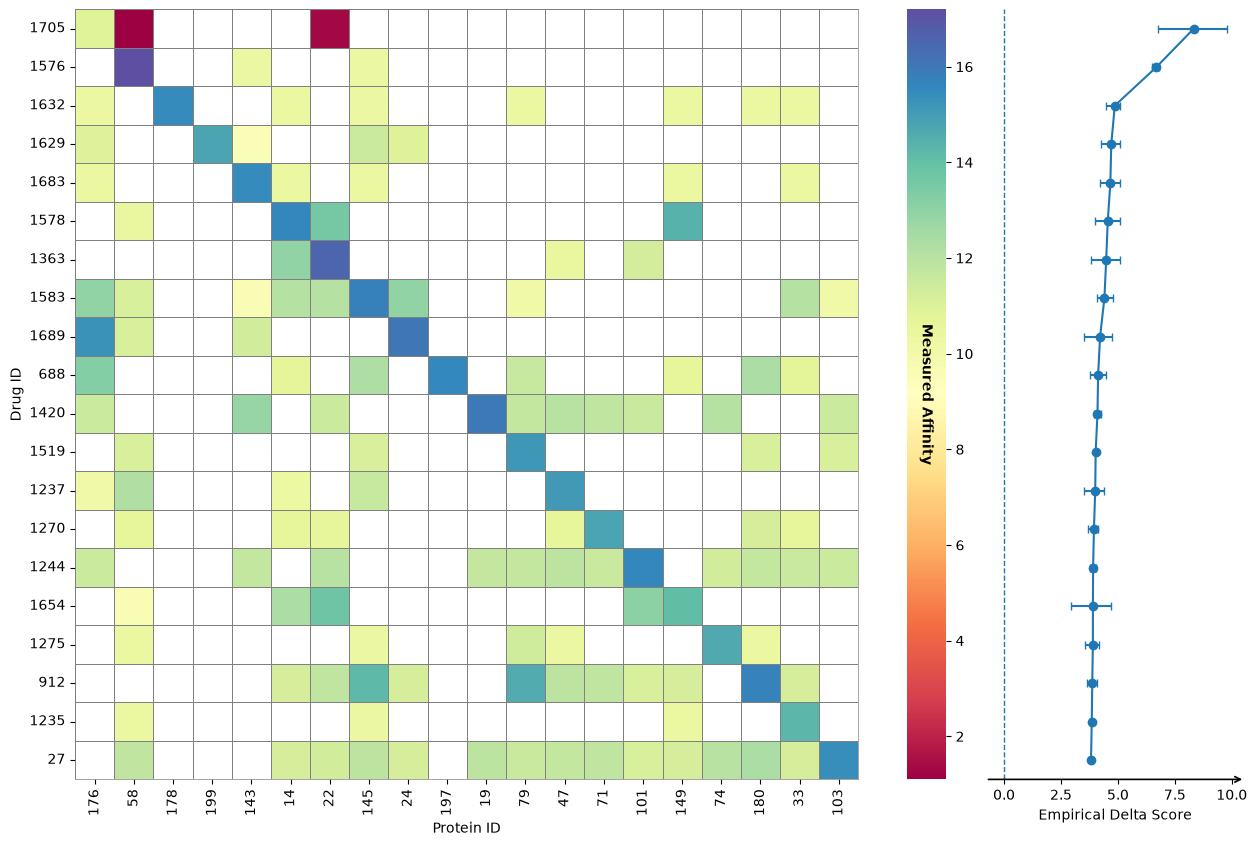

In [17]:
def bootstrap_selectivity_ci(x, best_target, n_boot=2000, ci=0.95):
    best_affinity = x.loc[x["protein_id"] == best_target, "affinity"].mean()
    off_target = x.loc[x["protein_id"] != best_target, "affinity"].values

    boot = np.empty(n_boot)
    for i in range(n_boot):
        sample = np.random.choice(off_target, size=len(off_target), replace=True)
        boot[i] = best_affinity - sample.mean()

    alpha = (1 - ci) / 2

    return np.quantile(boot, [alpha, 1 - alpha])

def calc_selectivity(x, best_target_lookup):
    best_target = best_target_lookup.loc[x.name]
    best_affinity = x.loc[x["protein_id"] == best_target, "affinity"].mean()

    off_target_affinity = x.loc[x["protein_id"] != best_target, "affinity"].mean()

    return best_affinity - off_target_affinity

def selectivity_plot(dataset, min_measurements=3):
    drug_counts = dataset.groupby("drug_id").size()

    eligible_drugs = drug_counts[drug_counts >= min_measurements].index
    dataset_filtered = dataset[dataset["drug_id"].isin(eligible_drugs)]

    best_idx = dataset_filtered.groupby("drug_id")["affinity"].idxmax()
    drug_best_target = best_idx.apply(lambda idx: dataset_filtered.loc[idx, "protein_id"])

    selectivity = dataset_filtered.groupby("drug_id").apply(
        lambda x: calc_selectivity(x, drug_best_target),
        include_groups=False)

    ranked_drugs = selectivity.sort_values(ascending=False).index

    top_drugs = []
    used_targets = set()
    for drug_id in ranked_drugs:
        target = drug_best_target.loc[drug_id]

        if target in used_targets:
            continue

        top_drugs.append(drug_id)
        used_targets.add(target)

        if len(top_drugs) == 20:
            break

    # Column i = best target of drug i
    top_proteins = drug_best_target.loc[top_drugs].tolist()

    data = dataset[dataset["drug_id"].isin(top_drugs) & dataset["protein_id"].isin(top_proteins)]
    data = data.pivot_table(index="drug_id", columns="protein_id", values="affinity", aggfunc="mean")
    data = data.reindex(index=top_drugs, columns=top_proteins)

    cis = []
    for drug_id in top_drugs:
        x = dataset_filtered[dataset_filtered["drug_id"] == drug_id]

        ci_low, ci_high = bootstrap_selectivity_ci(x, best_target=drug_best_target.loc[drug_id], n_boot=2000, ci=0.95)
        cis.append((ci_low, ci_high))

    cis = np.asarray(cis)
    sel = selectivity.loc[top_drugs].values
    xerr = np.vstack([sel - cis[:, 0], cis[:, 1] - sel,])

    fig, (ax_heat, ax_sel) = plt.subplots(1, 2, figsize=(15, 10), sharey=True,
        gridspec_kw={"width_ratios": [4, 1], "wspace": -0.1})

    sns.heatmap(data, cmap="Spectral", cbar_kws={"label": "Affinity"}, ax=ax_heat,
        linewidths=0.5, linecolor="gray")

    for spine in ax_heat.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_edgecolor("gray")

    ax_heat.set_xlabel("Protein ID")
    ax_heat.set_ylabel("Drug ID")

    ax_heat.set_yticklabels(data.index, rotation=0)

    ax_heat.set_xticklabels(data.columns, rotation=90)
    cbar = ax_heat.collections[0].colorbar

    # Remove normal colorbar label
    cbar.set_label("")

    # Put label inside the colorbar
    cbar.ax.text(0.5, 0.5, "Measured Affinity", rotation=270, ha="center", va="center",
        transform=cbar.ax.transAxes, fontweight="bold")

    y = np.arange(len(top_drugs)) + 0.5

    ax_sel.errorbar(sel, y, xerr=xerr, fmt="o-", capsize=3)
    ax_sel.axvline(0, linestyle="--", linewidth=1)
    ax_sel.set_xlabel("Empirical Delta Score")
    ax_sel.set_ylabel("")

    for spine in ax_sel.spines.values():
        spine.set_visible(False)

    # Keep x ticks, remove y ticks
    ax_sel.tick_params(axis="y", left=False, labelleft=False)

    # Draw x-axis as an arrow
    ax_sel.annotate("",
        xy=(1.03, 0),          # arrow tip
        xytext=(-0.03, 0),     # arrow start
        xycoords=("axes fraction", "axes fraction"),
        arrowprops=dict(arrowstyle="->", linewidth=1.2), annotation_clip=False)

    # Hide duplicated drug labels on right panel
    ax_sel.tick_params(axis="y", left=False, labelleft=False)

    plt.show()

selectivity_plot(kiba, 5)

In [18]:
bindingdb_drugs = pd.read_csv('../data/bindingdb/drugs.csv')
bindingdb_proteins = pd.read_csv('../data/bindingdb/proteins.csv')
bindingdb = pd.read_csv('../data/bindingdb/affinities.csv')

bindingdb = bindingdb.merge(bindingdb_drugs, on='drug_id')
bindingdb = bindingdb.merge(bindingdb_proteins, on='protein_id')

bindingdb.head()

,drug_id,protein_id,affinity,smiles,target_sequence
0,26799,1834,5.187087,BP(=O)(COCCn1cnc2c(N)ncnc21)OP(=O)(O)OP(=O)(O)O,PISPITVPVKLKPGMDGPKVKQWPLTEEKIKALTEICTEMEKEGKI...
1,26798,1834,4.481486,BP(=O)(CO[C@H](C)Cn1cnc2c(N)ncnc21)OP(=O)(O)OP...,PISPITVPVKLKPGMDGPKVKQWPLTEEKIKALTEICTEMEKEGKI...
2,19212,1038,4.922332,Br[Se]c1ccccc1,MACTIQKAEALDGAHLMQILWYDEEESLYPAVWLRDNCPCSDCYLD...
3,2112,466,7.742321,Brc1c(Br)c(Br)c2[nH]cnc2c1Br,MAGKKVLIVYAHQEPKSFNGSLKNVAVDELSRQGCTVTVSDLYAMN...
4,2111,466,5.148130,Brc1c(Br)c(Br)c2[nH]nnc2c1Br,MAGKKVLIVYAHQEPKSFNGSLKNVAVDELSRQGCTVTVSDLYAMN...


In [19]:
n_drugs = bindingdb['drug_id'].nunique()
n_proteins = bindingdb['protein_id'].nunique()
n_affs = len(bindingdb)

print(f"Number of drugs: {n_drugs}\nNumber of proteins: {n_proteins}\nMeasured affinities: {n_affs} / {n_drugs * n_proteins} = {100 * n_affs / (n_drugs * n_proteins):.2f}%")

Number of drugs: 35037
Number of proteins: 4169
Measured affinities: 86949 / 146069253 = 0.06%


In [20]:
bindingdb['Protein Length'] = bindingdb['target_sequence'].str.len()
bindingdb['SMILES Length'] = bindingdb['smiles'].str.len()

bindingdb.head()

,drug_id,protein_id,affinity,smiles,target_sequence,Protein Length,SMILES Length
0,26799,1834,5.187087,BP(=O)(COCCn1cnc2c(N)ncnc21)OP(=O)(O)OP(=O)(O)O,PISPITVPVKLKPGMDGPKVKQWPLTEEKIKALTEICTEMEKEGKI...,254,47
1,26798,1834,4.481486,BP(=O)(CO[C@H](C)Cn1cnc2c(N)ncnc21)OP(=O)(O)OP...,PISPITVPVKLKPGMDGPKVKQWPLTEEKIKALTEICTEMEKEGKI...,254,54
2,19212,1038,4.922332,Br[Se]c1ccccc1,MACTIQKAEALDGAHLMQILWYDEEESLYPAVWLRDNCPCSDCYLD...,387,14
3,2112,466,7.742321,Brc1c(Br)c(Br)c2[nH]cnc2c1Br,MAGKKVLIVYAHQEPKSFNGSLKNVAVDELSRQGCTVTVSDLYAMN...,231,28
4,2111,466,5.148130,Brc1c(Br)c(Br)c2[nH]nnc2c1Br,MAGKKVLIVYAHQEPKSFNGSLKNVAVDELSRQGCTVTVSDLYAMN...,231,28


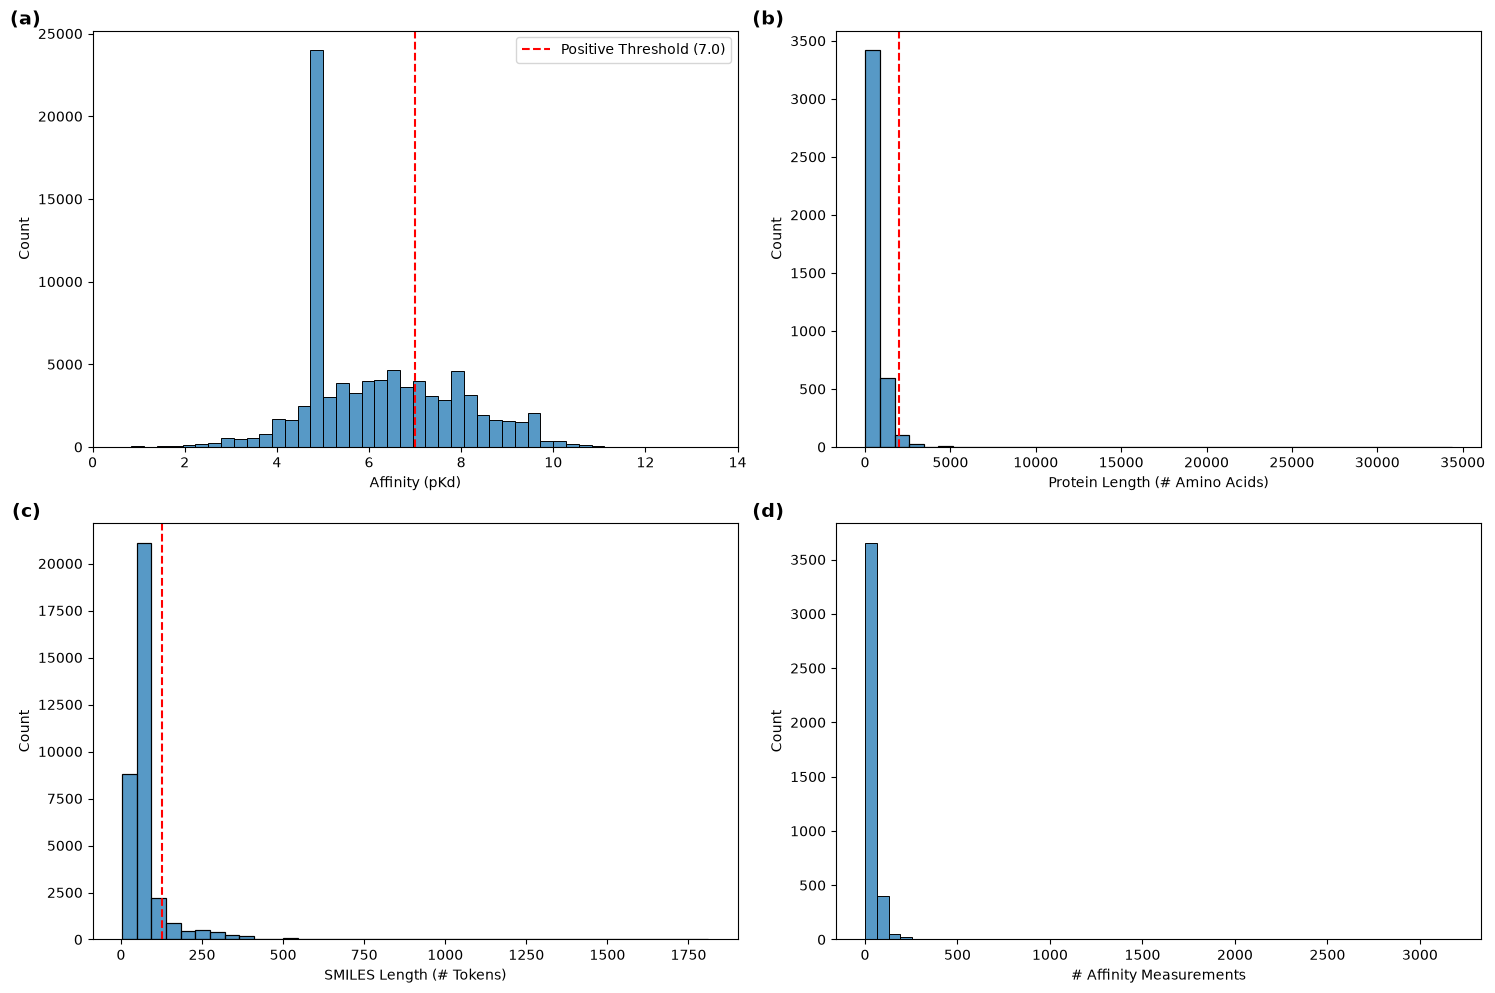

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Affinity
sns.histplot(bindingdb['affinity'], bins=50, ax=axes[0, 0])
axes[0, 0].axvline(
    7, color='red', linestyle='--',
    label='Positive Threshold (7.0)'
)
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 14)
axes[0, 0].set_xlabel('Affinity (pKd)')

# Protein length
sns.histplot(
    bindingdb.drop_duplicates('protein_id')['Protein Length'],
    bins=40,
    ax=axes[0, 1]
)
axes[0, 1].axvline(2000, color='red', linestyle='--')
axes[0, 1].set_xlabel('Protein Length (# Amino Acids)')

# SMILES length
sns.histplot(
    bindingdb.drop_duplicates('drug_id')['SMILES Length'],
    bins=40,
    ax=axes[1, 0]
)
axes[1, 0].axvline(128, color='red', linestyle='--')
axes[1, 0].set_xlabel('SMILES Length (# Tokens)')

# Number of affinity measurements per protein
measurements_per_protein = bindingdb.groupby('protein_id').size()

sns.histplot(
    measurements_per_protein,
    bins=50,
    ax=axes[1, 1]
)
axes[1, 1].set_xlabel('# Affinity Measurements')

for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(
        -0.08, 1.05,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='right'
    )


plt.tight_layout()
plt.show()

In [22]:
print(bindingdb['affinity'].describe())

count    86949.000000
mean         6.212104
std          1.617849
min         -0.543074
25%          5.000000
50%          5.884776
75%          7.376751
max         13.327902
Name: affinity, dtype: float64


In [23]:
print("Number of proteins with less than 50 amino acids:", (bindingdb.drop_duplicates('protein_id')['Protein Length'] < 50).sum())
print("Number of proteins with more than 2000 amino acids:", (bindingdb.drop_duplicates('protein_id')['Protein Length'] > 2000).sum())
print("Number of proteins with less than 5 affinity measurements:", (bindingdb.groupby('protein_id').size() < 5).sum())

Number of proteins with less than 50 amino acids: 6
Number of proteins with more than 2000 amino acids: 110
Number of proteins with less than 5 affinity measurements: 2853


In [24]:
print("Number of drugs with SMILES length greater than 128:", (bindingdb.drop_duplicates('drug_id')['SMILES Length'] > 128).sum())

Number of drugs with SMILES length greater than 128: 3194


In [25]:
print("Before filters:")
print("Number of drugs:", bindingdb['drug_id'].nunique())
print("Number of proteins:", bindingdb['protein_id'].nunique())
print("Number of measured affinities:", len(bindingdb))
print("Density of measured affinities: {:.2f}%".format(100 * len(bindingdb) / (bindingdb['drug_id'].nunique() * bindingdb['protein_id'].nunique())))
print("After filters:")
bindingdb_filtered = bindingdb[(bindingdb['Protein Length'] >= 50) & (bindingdb['Protein Length'] <= 2000) & (bindingdb['SMILES Length'] <= 126) & ~bindingdb['smiles'].str.contains('.', regex=False)]
# only proteins with at least 5 affinity measurements
protein_counts = bindingdb_filtered['protein_id'].value_counts()
bindingdb_filtered = bindingdb_filtered[bindingdb_filtered['protein_id'].isin(protein_counts[protein_counts >= 5].index)]
print("Number of drugs after filters:", bindingdb_filtered['drug_id'].nunique())
print("Number of proteins after filters:", bindingdb_filtered['protein_id'].nunique())
print("Number of measured affinities after filters:", len(bindingdb_filtered))
print("Density of measured affinities after filters: {:.2f}%".format(100 * len(bindingdb_filtered) / (bindingdb_filtered['drug_id'].nunique() * bindingdb_filtered['protein_id'].nunique())))

Before filters:
Number of drugs: 35037
Number of proteins: 4169
Number of measured affinities: 86949
Density of measured affinities: 0.06%
After filters:
Number of drugs after filters: 30515
Number of proteins after filters: 1180
Number of measured affinities after filters: 76316
Density of measured affinities after filters: 0.21%


In [26]:
subset = bindingdb[bindingdb['SMILES Length'] > 128].drop_duplicates('drug_id')

mols = [m for m in subset['smiles'].apply(Chem.MolFromSmiles) if m is not None][:10]

opts = Draw.MolDrawOptions()
opts.padding = 0.0

svg = Draw._MolsToGridSVG(
    mols,
    molsPerRow=5,
    subImgSize=(400, 400),
    drawOptions=opts,
)
if isinstance(svg, bytes):
    svg = svg.decode("utf-8", errors="replace")
HTML(svg)

In [27]:
protein_stats = bindingdb_filtered.groupby("protein_id")["affinity"].agg(
    affinities=list,
    mean="mean",
    n="size",
    ci95=ci95
)

protein_stats[["ci_low", "ci_high"]] = pd.DataFrame(
    protein_stats["ci95"].tolist(),
    index=protein_stats.index,
    columns=["ci_low", "ci_high"],
)

protein_stats

,affinities,mean,n,ci95,ci_low,ci_high
protein_id,,,,,,
10,"[7.259637310505756, 7.745318094244641, 8.23428...",6.835890,579,"(6.661148738162157, 7.010630734128532)",6.661149,7.010631
11,"[8.698970004336019, 8.4089353929735, 8.4089353...",8.513864,11,"(8.405019503721533, 8.622708892711557)",8.405020,8.622709
12,"[5.968755770918705, 4.878569643379604, 6.01810...",6.073438,378,"(5.851539384495787, 6.295335717643562)",5.851539,6.295336
13,"[4.6020599913279625, 3.5228787452803374, 7.327...",5.674908,38,"(5.2779800444762035, 6.071836693802707)",5.277980,6.071837
14,"[6.0, 5.0, 7.698970004336019, 9.0, 5.698970004...",7.342563,7,"(5.7167871891358475, 8.96833852762759)",5.716787,8.968339
...,...,...,...,...,...,...
2315,"[5.301029995663981, 6.122091146049044, 7.06333...",6.147308,11,"(5.525968697472132, 6.768646305553533)",5.525969,6.768646
2321,"[6.667420657353922, 6.709971099356649, 6.74316...",6.551252,9,"(5.783804743273992, 7.318698762324704)",5.783805,7.318699
2327,"[7.744727494896693, 7.102372908709558, 7.72124...",6.308146,11,"(5.311739688128654, 7.304552076312536)",5.311740,7.304552


In [28]:
protein_stats['ci_low'].describe(), protein_stats['ci_high'].describe()

(count    1180.000000
 mean        5.478186
 std         1.251294
 min         1.142976
 25%         4.954385
 50%         5.294931
 75%         6.078373
 max        10.722977
 Name: ci_low, dtype: float64,
 count    1180.000000
 mean        6.416744
 std         1.385771
 min         2.496800
 25%         5.480579
 50%         6.102913
 75%         7.200713
 max        12.449104
 Name: ci_high, dtype: float64)

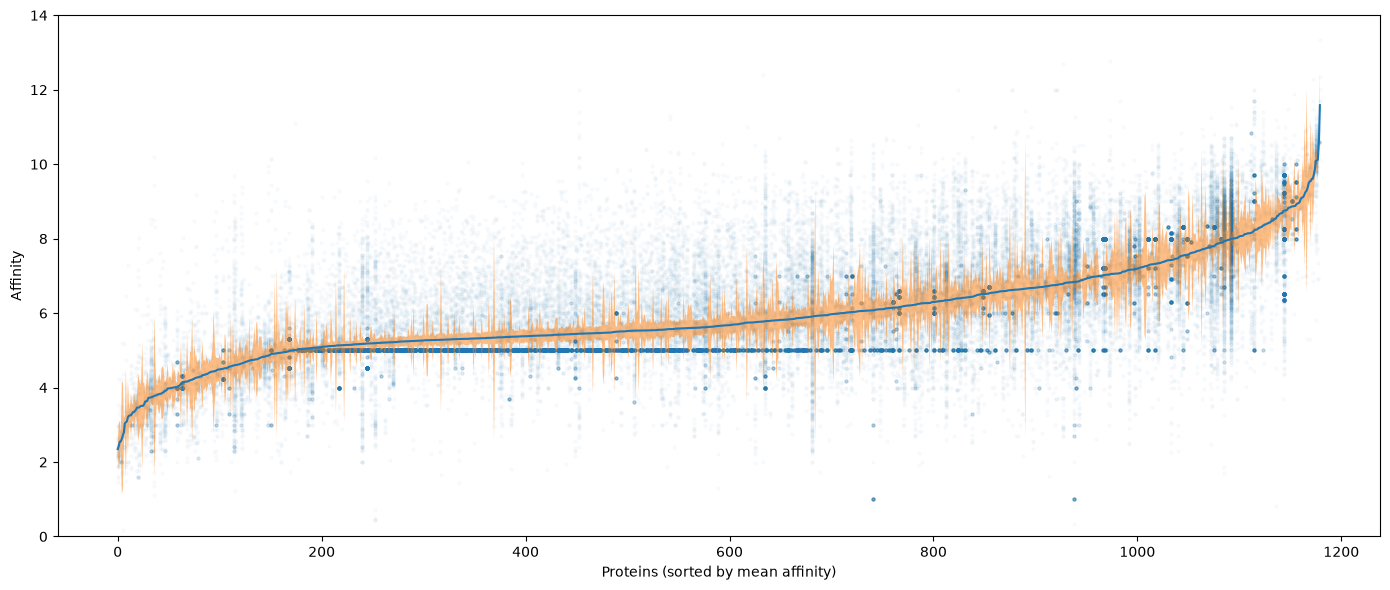

In [29]:
protein_stats = protein_stats.sort_values("mean").reset_index(drop=True)
dots = protein_stats["affinities"].explode()

valid = ~np.isnan(protein_stats["ci_low"]) & ~np.isnan(protein_stats["ci_high"])

plt.figure(figsize=(14, 6))
plt.scatter(dots.index, dots.values, s=5, alpha=0.02)
plt.plot(protein_stats.index, protein_stats["mean"])
plt.fill_between(protein_stats.index, protein_stats["ci_low"], protein_stats["ci_high"],
                    alpha=0.5, where=valid, interpolate=True)

plt.xlabel("Proteins (sorted by mean affinity)")
plt.ylabel("Affinity")
plt.ylim(0, 14)
plt.tight_layout()
plt.show()

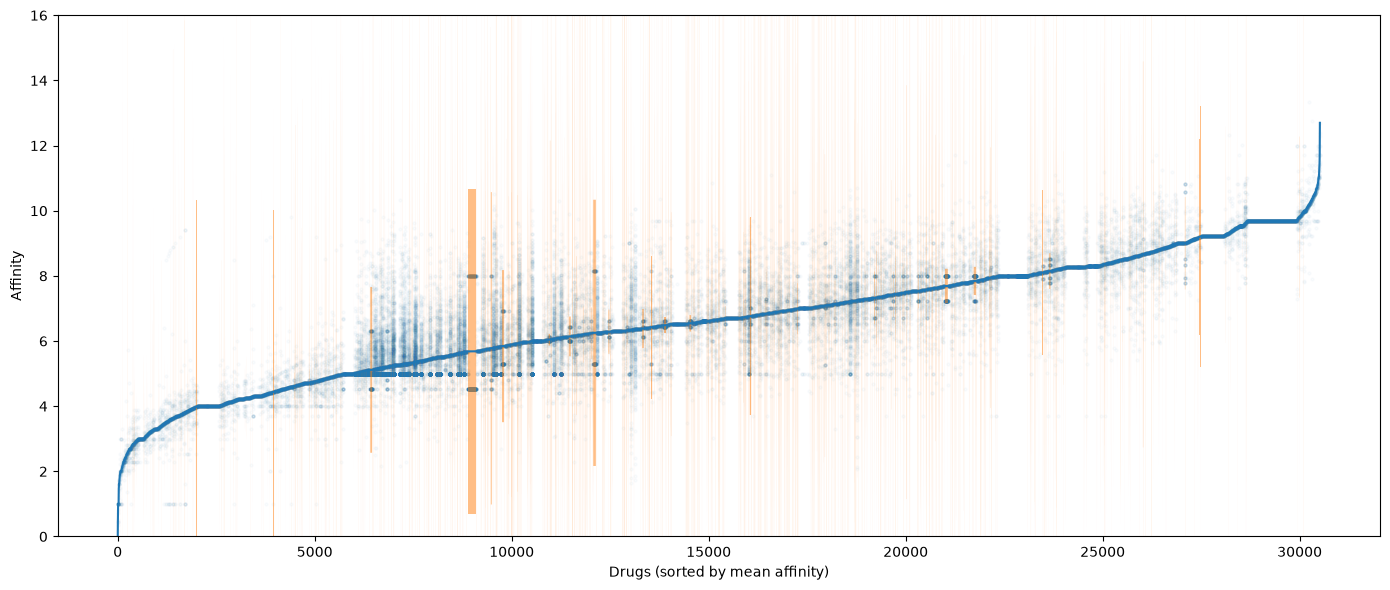

In [30]:
drug_stats = bindingdb_filtered.groupby("drug_id")["affinity"].agg(
    affinities=list,
    mean="mean",
    n="size",
    ci95=ci95
)

drug_stats[["ci_low", "ci_high"]] = pd.DataFrame(
    drug_stats["ci95"].tolist(),
    index=drug_stats.index,
    columns=["ci_low", "ci_high"],
)

drug_stats = drug_stats.sort_values("mean").reset_index(drop=True)
dots = drug_stats["affinities"].explode()

plt.figure(figsize=(14, 6))
plt.scatter(dots.index, dots.values, s=5, alpha=0.02)
plt.plot(drug_stats.index, drug_stats["mean"])
plt.fill_between(drug_stats.index, drug_stats["ci_low"], drug_stats["ci_high"], alpha=0.5)

plt.xlabel("Drugs (sorted by mean affinity)")
plt.ylabel("Affinity")
plt.ylim(0, 16)
plt.tight_layout()
plt.show()

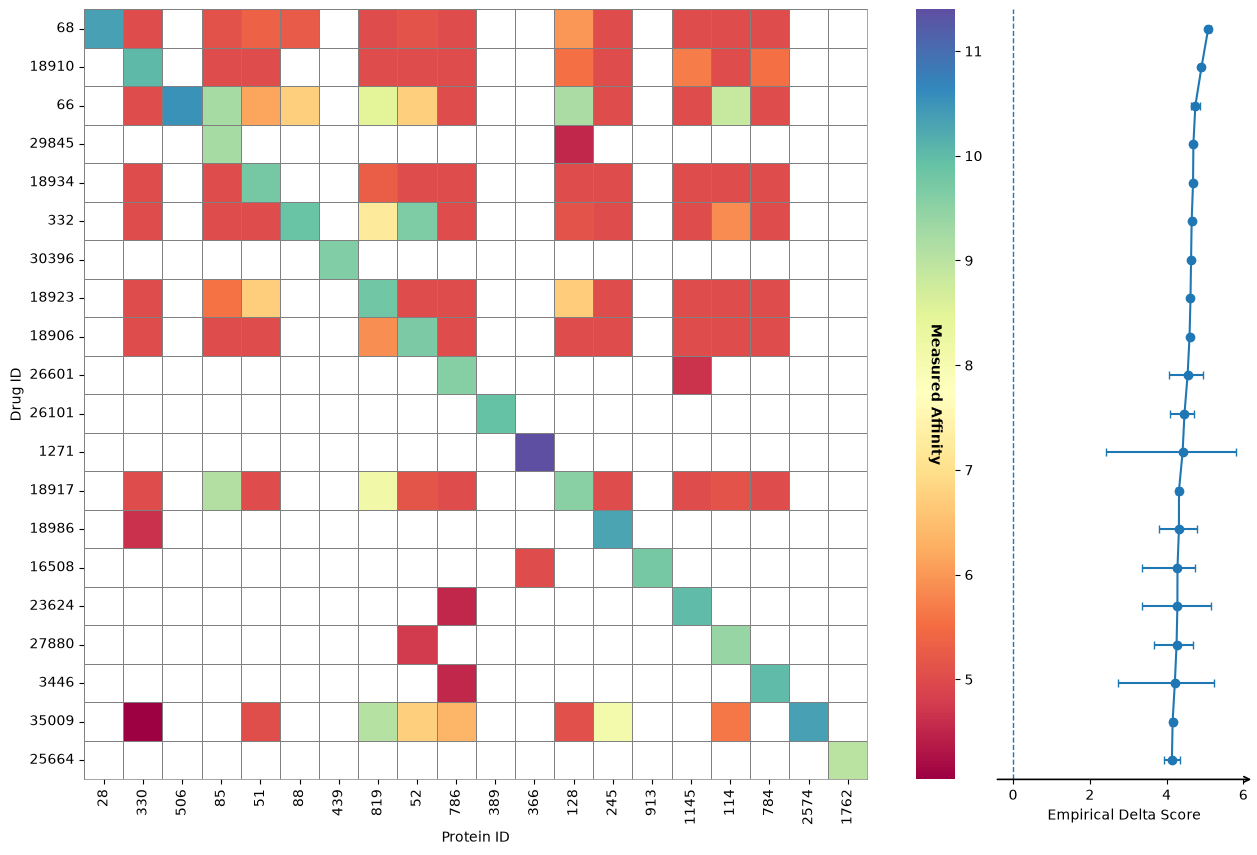

In [31]:
selectivity_plot(bindingdb, 5)

In [32]:
measurements_per_drug = bindingdb.groupby('drug_id').size()

print(f'Percentage of drugs measured against at least 2 proteins {(measurements_per_drug >= 2).mean() * 100}%')
print(f'Percentage of drugs measured against at least 3 proteins {(measurements_per_drug >= 3).mean() * 100}%')
print(f'Percentage of drugs measured against at least 4 proteins {(measurements_per_drug >= 4).mean() * 100}%')
print(f'Percentage of drugs measured against at least 5 proteins {(measurements_per_drug >= 5).mean() * 100}%')

Percentage of drugs measured against at least 2 proteins 24.194423038502155%
Percentage of drugs measured against at least 3 proteins 11.079715729086393%
Percentage of drugs measured against at least 4 proteins 5.542711990181807%
Percentage of drugs measured against at least 5 proteins 4.1441904272626084%


In [33]:
papyrus_drugs = pd.read_csv('../data/papyrus/drugs.csv')
papyrus_proteins = pd.read_csv('../data/papyrus/proteins.csv')
papyrus = pd.read_csv('../data/papyrus/affinities.csv')

papyrus = papyrus.merge(papyrus_drugs, on='drug_id')
papyrus = papyrus.merge(papyrus_proteins, on='protein_id')

papyrus.head()

,drug_id,protein_id,affinity,smiles,target_sequence
0,0,0,9.030,CN1CCCC1Cc1c[nH]c2ccc(OC3CCCCC3)cc12,MVPEPGPTANSTPAWGAGPPSAPGGSGWVAAALCVVIALTAAANSL...
1,1,1,6.905,COc1cccc(-c2cc(F)c(C3CC3N)cc2F)c1,MLSGKKAAAAAAAAAAAATGTEAGPGTAGGSENGSEVAAQPAGLSG...
2,1,2,4.615,COc1cccc(-c2cc(F)c(C3CC3N)cc2F)c1,MATPRGRTKKKASFDHSPDSLPLRSSGRQAKKKATETTDEDEDGGS...
3,2,3,9.085,CCOCC(=O)NC1CCCOc2c1nn(-c1ccccc1Cl)c2-c1ccc(Cl...,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...
4,2,4,5.180,CCOCC(=O)NC1CCCOc2c1nn(-c1ccccc1Cl)c2-c1ccc(Cl...,MEECWVTEIANGSKDGLDSNPMKDYMILSGPQKTAVAVLCTLLGLL...


In [34]:
n_drugs = papyrus['drug_id'].nunique()
n_proteins = papyrus['protein_id'].nunique()
n_affs = len(papyrus)

print(f"Number of drugs: {n_drugs}\nNumber of proteins: {n_proteins}\nMeasured affinities: {n_affs} / {n_drugs * n_proteins} = {100 * n_affs / (n_drugs * n_proteins):.2f}%")

Number of drugs: 82248
Number of proteins: 1068
Measured affinities: 241500 / 87840864 = 0.27%


In [35]:
papyrus['Protein Length'] = papyrus['target_sequence'].str.len()
papyrus['SMILES Length'] = papyrus['smiles'].str.len()

papyrus.head()

,drug_id,protein_id,affinity,smiles,target_sequence,Protein Length,SMILES Length
0,0,0,9.030,CN1CCCC1Cc1c[nH]c2ccc(OC3CCCCC3)cc12,MVPEPGPTANSTPAWGAGPPSAPGGSGWVAAALCVVIALTAAANSL...,440,36
1,1,1,6.905,COc1cccc(-c2cc(F)c(C3CC3N)cc2F)c1,MLSGKKAAAAAAAAAAAATGTEAGPGTAGGSENGSEVAAQPAGLSG...,852,33
2,1,2,4.615,COc1cccc(-c2cc(F)c(C3CC3N)cc2F)c1,MATPRGRTKKKASFDHSPDSLPLRSSGRQAKKKATETTDEDEDGGS...,822,33
3,2,3,9.085,CCOCC(=O)NC1CCCOc2c1nn(-c1ccccc1Cl)c2-c1ccc(Cl...,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,472,50
4,2,4,5.180,CCOCC(=O)NC1CCCOc2c1nn(-c1ccccc1Cl)c2-c1ccc(Cl...,MEECWVTEIANGSKDGLDSNPMKDYMILSGPQKTAVAVLCTLLGLL...,360,50


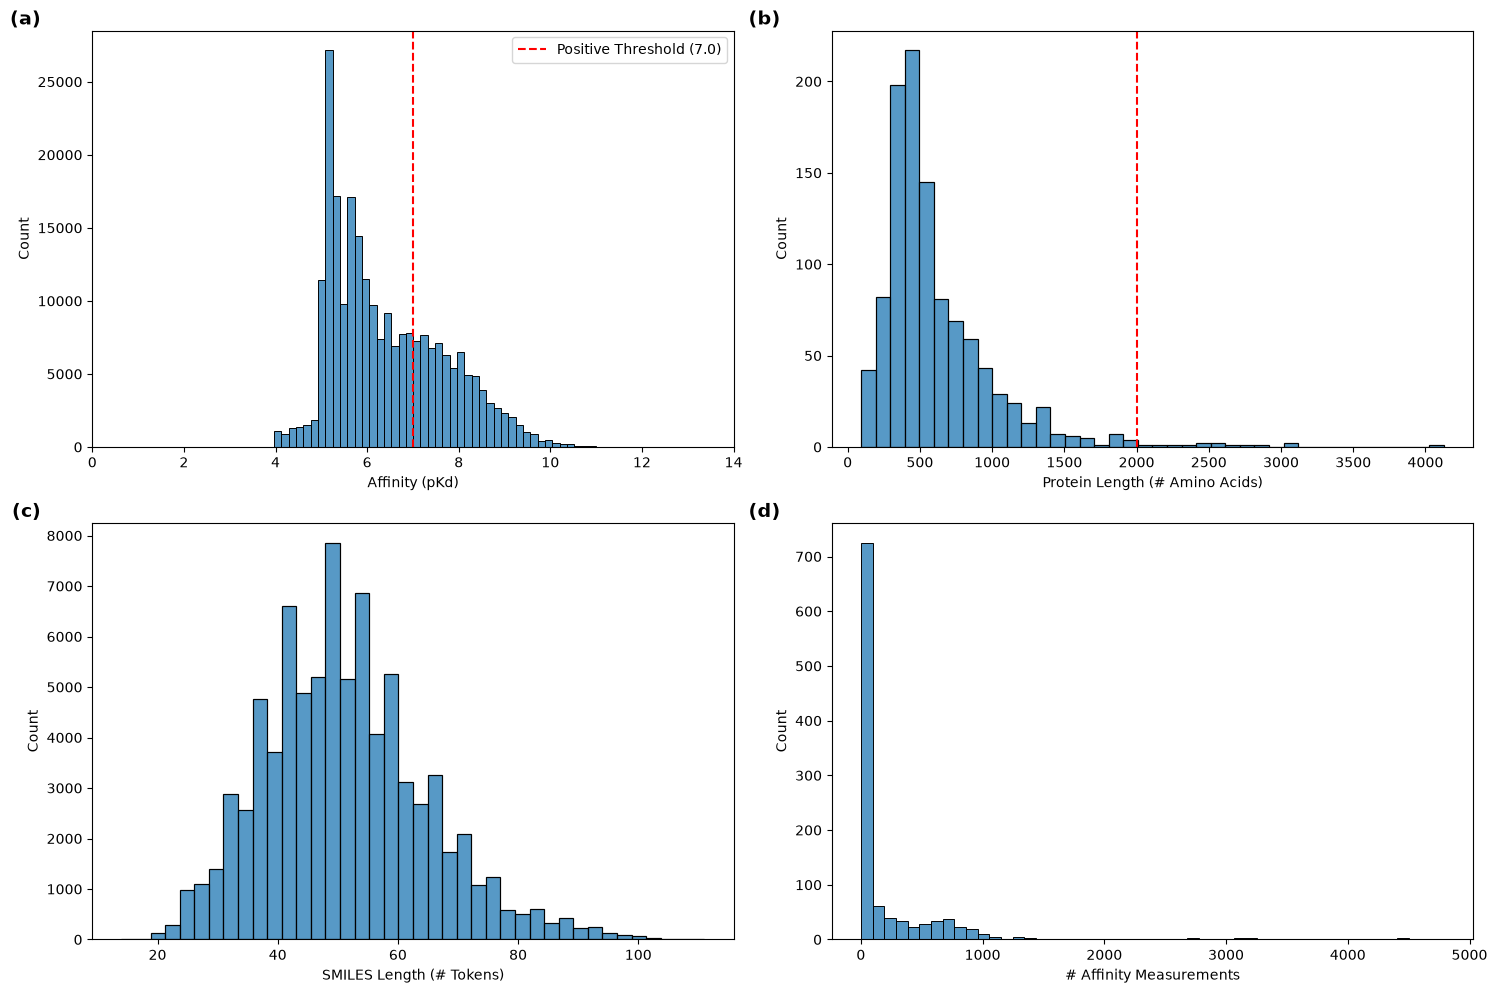

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Affinity
sns.histplot(papyrus['affinity'], bins=50, ax=axes[0, 0])
axes[0, 0].axvline(
    7, color='red', linestyle='--',
    label='Positive Threshold (7.0)'
)
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 14)
axes[0, 0].set_xlabel('Affinity (pKd)')

# Protein length
sns.histplot(
    papyrus.drop_duplicates('protein_id')['Protein Length'],
    bins=40,
    ax=axes[0, 1]
)
axes[0, 1].axvline(2000, color='red', linestyle='--')
axes[0, 1].set_xlabel('Protein Length (# Amino Acids)')

# SMILES length
sns.histplot(
    papyrus.drop_duplicates('drug_id')['SMILES Length'],
    bins=40,
    ax=axes[1, 0]
)
axes[1, 0].set_xlabel('SMILES Length (# Tokens)')

# Number of affinity measurements per protein
measurements_per_protein = papyrus.groupby('protein_id').size()

sns.histplot(
    measurements_per_protein,
    bins=50,
    ax=axes[1, 1]
)
axes[1, 1].set_xlabel('# Affinity Measurements')

for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(
        -0.08, 1.05,
        label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='right'
    )

plt.tight_layout()
plt.show()

In [37]:
print(papyrus['affinity'].describe())

count    241500.000000
mean          6.438122
std           1.260708
min           3.010000
25%           5.400000
50%           6.100000
75%           7.340000
max          11.000000
Name: affinity, dtype: float64


In [38]:
print("Number of proteins with less than 50 amino acids:", (papyrus.drop_duplicates('protein_id')['Protein Length'] < 50).sum())
print("Number of proteins with more than 2000 amino acids:", (papyrus.drop_duplicates('protein_id')['Protein Length'] > 2000).sum())
print("Number of proteins with less than 5 affinity measurements:", (papyrus.groupby('protein_id').size() < 5).sum())

Number of proteins with less than 50 amino acids: 0
Number of proteins with more than 2000 amino acids: 15
Number of proteins with less than 5 affinity measurements: 309


In [39]:
print("Number of drugs with SMILES length greater than 128:", (papyrus.drop_duplicates('drug_id')['SMILES Length'] > 128).sum())

Number of drugs with SMILES length greater than 128: 0


In [40]:
print("Before filters:")
print("Number of drugs:", papyrus['drug_id'].nunique())
print("Number of proteins:", papyrus['protein_id'].nunique())
print("Number of measured affinities:", len(papyrus))
print("Density of measured affinities: {:.2f}%".format(100 * len(papyrus) / (papyrus['drug_id'].nunique() * papyrus['protein_id'].nunique())))
print("After filters:")
papyrus_filtered = papyrus[(papyrus['Protein Length'] >= 50) & (papyrus['Protein Length'] <= 2000) & (papyrus['SMILES Length'] <= 126) & ~papyrus['smiles'].str.contains('.', regex=False)]
# only proteins with at least 5 affinity measurements
protein_counts = papyrus_filtered['protein_id'].value_counts()
papyrus_filtered = papyrus_filtered[papyrus_filtered['protein_id'].isin(protein_counts[protein_counts >= 5].index)]
print("Number of drugs after filters:", papyrus_filtered['drug_id'].nunique())
print("Number of proteins after filters:", papyrus_filtered['protein_id'].nunique())
print("Number of measured affinities after filters:", len(papyrus_filtered))
print("Density of measured affinities after filters: {:.2f}%".format(100 * len(papyrus_filtered) / (papyrus_filtered['drug_id'].nunique() * papyrus_filtered['protein_id'].nunique())))

Before filters:
Number of drugs: 82248
Number of proteins: 1068
Number of measured affinities: 241500
Density of measured affinities: 0.27%
After filters:
Number of drugs after filters: 81147
Number of proteins after filters: 749
Number of measured affinities after filters: 239226
Density of measured affinities after filters: 0.39%


In [41]:
papyrus

,drug_id,protein_id,affinity,smiles,target_sequence,Protein Length,SMILES Length
0,0,0,9.030,CN1CCCC1Cc1c[nH]c2ccc(OC3CCCCC3)cc12,MVPEPGPTANSTPAWGAGPPSAPGGSGWVAAALCVVIALTAAANSL...,440,36
1,1,1,6.905,COc1cccc(-c2cc(F)c(C3CC3N)cc2F)c1,MLSGKKAAAAAAAAAAAATGTEAGPGTAGGSENGSEVAAQPAGLSG...,852,33
2,1,2,4.615,COc1cccc(-c2cc(F)c(C3CC3N)cc2F)c1,MATPRGRTKKKASFDHSPDSLPLRSSGRQAKKKATETTDEDEDGGS...,822,33
3,2,3,9.085,CCOCC(=O)NC1CCCOc2c1nn(-c1ccccc1Cl)c2-c1ccc(Cl...,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,472,50
4,2,4,5.180,CCOCC(=O)NC1CCCOc2c1nn(-c1ccccc1Cl)c2-c1ccc(Cl...,MEECWVTEIANGSKDGLDSNPMKDYMILSGPQKTAVAVLCTLLGLL...,360,50
...,...,...,...,...,...,...,...
241495,82245,5,7.300,CC1(F)CCN(c2nc(-c3cnc(N)nc3)cc(N3CC4CC3CO4)n2)C1,MACLHETRTPSPSFGGFVSTLSEASMRKLDPDTSDCTPEKDLTPTH...,859,48
241496,82246,385,9.500,CC(C)c1cc(-c2ccc(F)c3ccccc23)nc(N)n1,MEEPGAQCAPPPPAGSETWVPQANLSSAPSQNCSAKDYIYQDSISL...,390,36
241497,82246,36,9.520,CC(C)c1cc(-c2ccc(F)c3ccccc23)nc(N)n1,MALSYRVSELQSTIPEHILQSTFVHVISSNWSGLQTESIPEEMKQI...,481,36
241498,82247,343,7.970,COc1ccc(C(=O)CC(Nc2ccc([N+](=O)[O-])cc2)C2CCCC...,MTELKAKGPRAPHVAGGPPSPEVGSPLLCRPAAGPFPGSQTSDTLP...,933,52


In [42]:
subset = papyrus[papyrus['SMILES Length'] > 128].drop_duplicates('drug_id')
print(subset)

Empty DataFrame
Columns: [drug_id, protein_id, affinity, smiles, target_sequence, Protein Length, SMILES Length]
Index: []


In [43]:
mols = [m for m in subset['smiles'].apply(Chem.MolFromSmiles) if m is not None][:10]

opts = Draw.MolDrawOptions()
opts.padding = 0.0

svg = Draw._MolsToGridSVG(
    mols,
    molsPerRow=5,
    subImgSize=(400, 400),
    drawOptions=opts,
)
if isinstance(svg, bytes):
    svg = svg.decode("utf-8", errors="replace")
HTML(svg)

In [44]:
protein_stats = papyrus_filtered.groupby("protein_id")["affinity"].agg(
    affinities=list,
    mean="mean",
    n="size",
    ci95=ci95
)

protein_stats[["ci_low", "ci_high"]] = pd.DataFrame(
    protein_stats["ci95"].tolist(),
    index=protein_stats.index,
    columns=["ci_low", "ci_high"],
)

protein_stats

,affinities,mean,n,ci95,ci_low,ci_high
protein_id,,,,,,
0,"[9.03, 6.88, 5.86, 7.85, 5.7, 8.57, 7.06, 9.64...",7.442720,3090,"(7.401617254724108, 7.483821926967986)",7.401617,7.483822
1,"[6.904999999999999, 8.05, 5.75, 5.4, 7.37, 4.9...",6.249215,121,"(6.055215740045276, 6.44321401202084)",6.055216,6.443214
2,"[4.615, 4.385, 4.46, 4.54, 4.06, 4.32, 5.08, 5...",4.484545,11,"(4.24559259188737, 4.723498317203539)",4.245593,4.723498
3,"[9.085, 6.26, 9.05, 6.82, 7.6, 5.84, 6.74, 7.5...",6.811734,2161,"(6.763797950365792, 6.859670505595954)",6.763798,6.859671
4,"[5.18, 6.21, 9.0, 8.15, 6.38, 8.17, 6.23, 9.15...",7.024528,2762,"(6.980775169213068, 7.068280535762623)",6.980775,7.068281
...,...,...,...,...,...,...
926,"[4.67, 4.75, 6.68, 4.76, 5.34, 4.76, 4.73, 4.7...",5.090000,9,"(4.586199810620053, 5.593800189379946)",4.586200,5.593800
930,"[10.22, 10.21, 10.09, 5.301, 6.558, 10.22, 10....",8.156778,9,"(6.279726973473493, 10.033828582082062)",6.279727,10.033829
955,"[4.89, 4.83, 5.635, 6.0, 5.21, 8.92]",5.914167,6,"(4.299227341299405, 7.529105992033928)",4.299227,7.529106


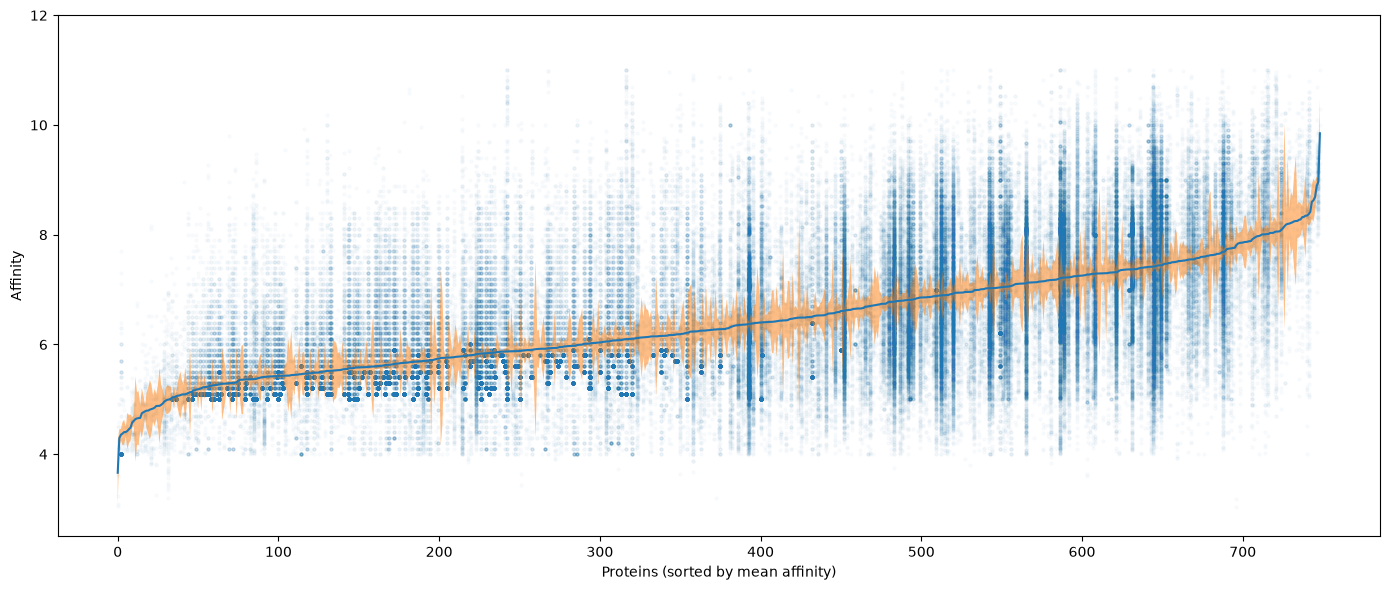

In [45]:
protein_stats = protein_stats.sort_values("mean").reset_index(drop=True)
dots = protein_stats["affinities"].explode()

plt.figure(figsize=(14, 6))
plt.scatter(dots.index, dots.values, s=5, alpha=0.02)
plt.plot(protein_stats.index, protein_stats["mean"])
plt.fill_between(protein_stats.index, protein_stats["ci_low"], protein_stats["ci_high"], alpha=0.5)

plt.xlabel("Proteins (sorted by mean affinity)")
plt.ylabel("Affinity")
plt.ylim(2.5, 12)
plt.tight_layout()
plt.show()

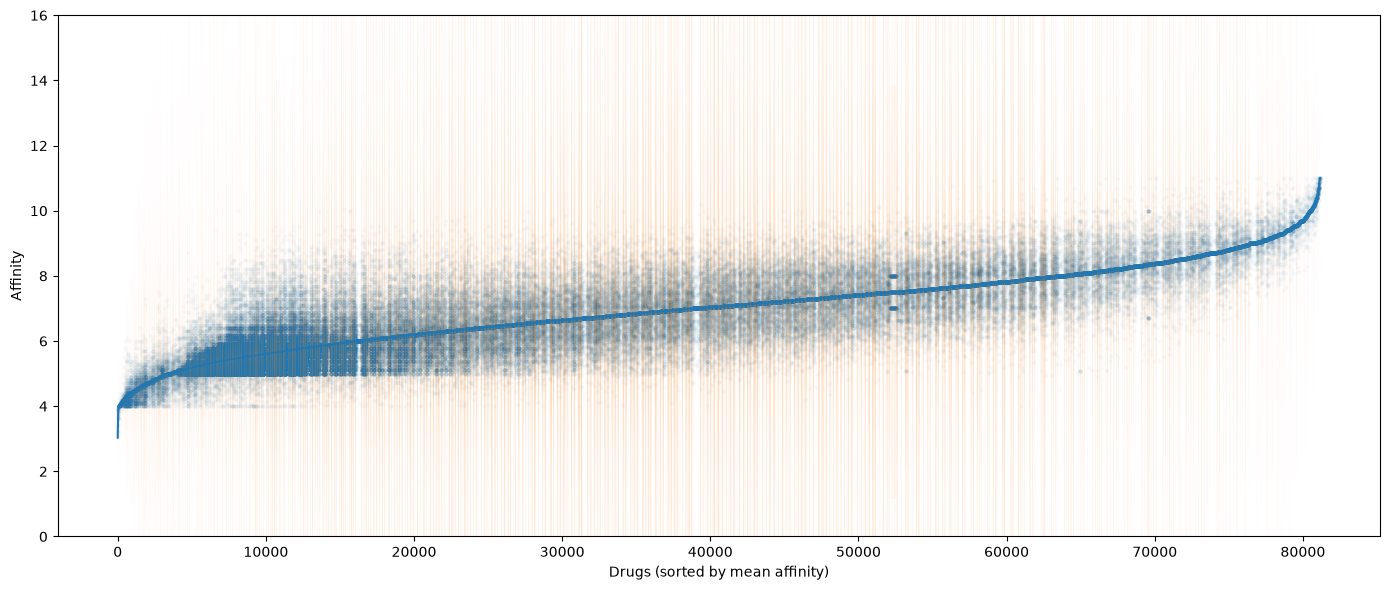

In [46]:
drug_stats = papyrus_filtered.groupby("drug_id")["affinity"].agg(
    affinities=list,
    mean="mean",
    n="size",
    ci95=ci95
)

drug_stats[["ci_low", "ci_high"]] = pd.DataFrame(
    drug_stats["ci95"].tolist(),
    index=drug_stats.index,
    columns=["ci_low", "ci_high"],
)

drug_stats = drug_stats.sort_values("mean").reset_index(drop=True)
dots = drug_stats["affinities"].explode()

plt.figure(figsize=(14, 6))
plt.scatter(dots.index, dots.values, s=5, alpha=0.02)
plt.plot(drug_stats.index, drug_stats["mean"])
plt.fill_between(drug_stats.index, drug_stats["ci_low"], drug_stats["ci_high"], alpha=0.5)

plt.xlabel("Drugs (sorted by mean affinity)")
plt.ylabel("Affinity")
plt.ylim(0, 16)
plt.tight_layout()
plt.show()

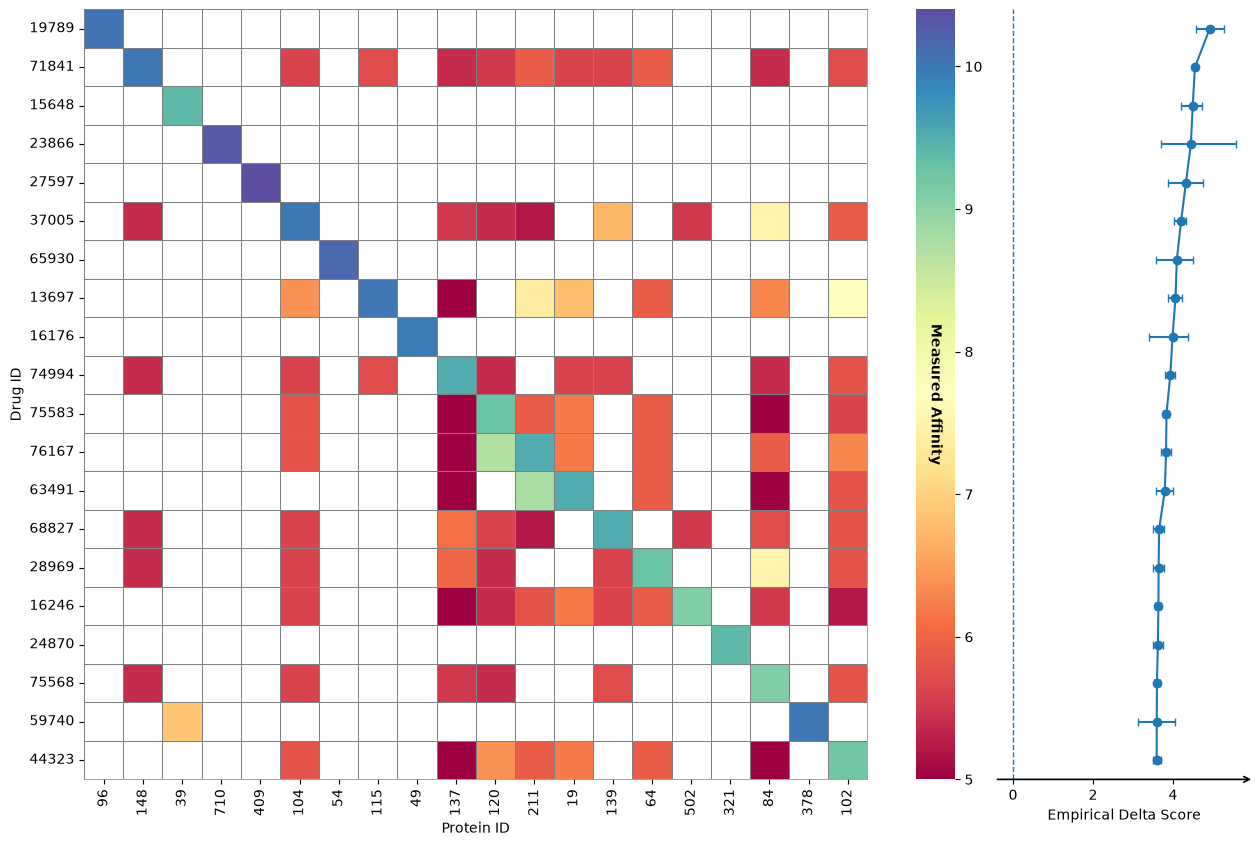

In [47]:
selectivity_plot(papyrus, 5)

In [48]:
measurements_per_drug = papyrus.groupby('drug_id').size()

print(f'Percentage of drugs measured against at least 2 proteins {(measurements_per_drug >= 2).mean() * 100}%')
print(f'Percentage of drugs measured against at least 3 proteins {(measurements_per_drug >= 3).mean() * 100}%')
print(f'Percentage of drugs measured against at least 4 proteins {(measurements_per_drug >= 4).mean() * 100}%')
print(f'Percentage of drugs measured against at least 5 proteins {(measurements_per_drug >= 5).mean() * 100}%')

Percentage of drugs measured against at least 2 proteins 40.23319715980936%
Percentage of drugs measured against at least 3 proteins 20.131796517848457%
Percentage of drugs measured against at least 4 proteins 10.636124890574846%
Percentage of drugs measured against at least 5 proteins 4.332020231494991%


In [49]:
datasets_info = [
    ('KIBA', kiba, kiba_filtered, 12.1),
    ('BindingDB', bindingdb, bindingdb_filtered, 7.0),
    ('Papyrus', papyrus, papyrus_filtered, 7.0),
]

summary_rows = []
for name, full_df, filt_df, threshold in datasets_info:
    n_drugs_full = full_df['drug_id'].nunique()
    n_proteins_full = full_df['protein_id'].nunique()
    n_affs_full = len(full_df)
    density_full = 100 * n_affs_full / (n_drugs_full * n_proteins_full)

    n_drugs_filt = filt_df['drug_id'].nunique()
    n_proteins_filt = filt_df['protein_id'].nunique()
    n_affs_filt = len(filt_df)
    density_filt = 100 * n_affs_filt / (n_drugs_filt * n_proteins_filt)

    pct_positive = 100 * (filt_df['affinity'] >= threshold).sum() / len(filt_df)

    summary_rows.append({
        'Dataset': name,
        'Drugs (raw)': n_drugs_full,
        'Proteins (raw)': n_proteins_full,
        'Affinity Records (raw)': n_affs_full,
        'Density % (raw)': round(density_full, 3),
        'Drugs (filtered)': n_drugs_filt,
        'Proteins (filtered)': n_proteins_filt,
        'Affinity Records (filtered)': n_affs_filt,
        'Density % (filtered)': round(density_filt, 3),
        'Drugs Removed': n_drugs_full - n_drugs_filt,
        'Proteins Removed': n_proteins_full - n_proteins_filt,
        'Affinity Records Removed': n_affs_full - n_affs_filt,
        'Positive Threshold': threshold,
        '% Positive (filtered)': round(pct_positive, 2),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Dataset,Drugs (raw),Proteins (raw),Affinity Records (raw),Density % (raw),Drugs (filtered),Proteins (filtered),Affinity Records (filtered),Density % (filtered),Drugs Removed,Proteins Removed,Affinity Records Removed,Positive Threshold,% Positive (filtered)
0,KIBA,2068,229,117657,24.845,2015,225,115829,25.548,53,4,1828,12.1,20.86
1,BindingDB,35037,4169,86949,0.060,30515,1180,76316,0.212,4522,2989,10633,7.0,30.19
2,Papyrus,82248,1068,241500,0.275,81147,749,239226,0.394,1101,319,2274,7.0,32.15


Drug fingerprints where computed with 2048 bits for all fingerprints, except MACCS, which is 167 bits, totalling 6311. Then, I PCA'd to 512 dimensions, which maintained 88.01% of the variance in KIBA, 75.51% in BindingDB, and 67.18% in Papyrus. Protein embeddings were encoded by the two models and also PCA'd to 128 dimensions, which maintained 99.0% of the variance in KIBA, 89.4% in BindingDB, and 92.8% in Papyrus.